# Normalizing Flow migliorato per Emerging Jets

Questo notebook parte dai file `.npz` già preprocessati e **non ricrea i dataset HDF5**, così evitiamo la parte pesante.

Rispetto al primo notebook RealNVP, qui correggiamo i problemi osservati:

1. **filtraggio dei jet senza tracce valide**, per evitare aggregate con slice vuote;
2. **robust scaling**, usando mediana e IQR del train background invece di mean/std;
3. **clipping delle feature**, per limitare outlier enormi;
4. **RealNVP più piccolo e più stabile**;
5. **learning rate più basso**;
6. **early stopping / best validation model**;
7. **scheduler sul learning rate**;
8. diagnostiche più chiare su NLL, quantili, train-vs-test-background e sampling.

Lo score di anomalia resta:

```text
score = NLL = -log p(x)
```

dove `x` è il vettore aggregato jet + track.

## 1. Import e GPU

In [1]:
from pathlib import Path
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path dei dataset preprocessati

In [2]:
# Questo notebook NON ricrea gli .npz.
# Usa i dataset già generati dal notebook precedente.

CANDIDATE_DATASETS = [
    {
        "name": "processed_flow",
        "dir": Path("processed_flow"),
        "files": {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed_clean",
        "dir": Path("processed_clean"),
        "files": {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed",
        "dir": Path("processed"),
        "files": {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        },
    },
]

selected = None

for candidate in CANDIDATE_DATASETS:
    base = candidate["dir"]
    files = {k: base / v for k, v in candidate["files"].items()}
    ok = all(path.exists() for path in files.values())

    print(candidate["name"], "available:", ok)
    for k, path in files.items():
        print(" ", k, "->", path, "exists:", path.exists())

    if ok and selected is None:
        selected = (candidate["name"], files)

if selected is None:
    raise FileNotFoundError(
        "Non ho trovato dataset preprocessati. "
        "Esegui prima il notebook che crea processed_flow/processed_clean .npz."
    )

DATASET_NAME, processed_files = selected
print("\nUsing dataset:", DATASET_NAME)
print(processed_files)

OUTPUT_DIR = Path("outputs_flow_stable")
OUTPUT_DIR.mkdir(exist_ok=True)

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True
processed_clean available: True
  val -> processed_clean\processed_clean_jet_track_val.npz exists: True
  test_background -> processed_clean\processed_clean_jet_track_test_background.npz exists: True
  test_signal -> processed_clean\processed_clean_jet_track_test_signal.npz exists: True
processed available: True
  val -> processed\processed_jet_track_val.npz exists: True
  test_background -> processed\processed_jet_track_test_background.npz exists: True
  test_signal -> processed\processed_jet_track_test_signal.npz exists: True

Using dataset: processed_flow
{'val': WindowsPath('processed_flow/processed_flow_jet_track_val.npz'), 'test_background': WindowsPath('processed_flow/processed_flow_jet_track_test_backg

## 3. Carica dataset

In [3]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nJet features:")
print(jet_feature_names)

print("\nTrack features:")
print(track_feature_names)

if "y" in data_train:
    print("\ntrain y:", np.unique(data_train["y"], return_counts=True))
if "meta_isDisplaced" in data_train:
    print("train meta_isDisplaced:", np.unique(data_train["meta_isDisplaced"], return_counts=True))

if "y" in data_sig:
    print("\nsignal y:", np.unique(data_sig["y"], return_counts=True))
if "meta_isDisplaced" in data_sig:
    print("signal meta_isDisplaced:", np.unique(data_sig["meta_isDisplaced"], return_counts=True))

train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)

Jet features:
['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features:
['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']

train y: (array([0]), array([100000]))
train meta_isDisplaced: (array([0], dtype=int32), array([100000]))

signal y: (array([1]), array([61966]))
signal meta_isDisplaced: (array([0, 1], dtype=int32), array([ 2322, 59644]))


## 4. Filtri: background-only train, signal displaced, jet con almeno una traccia

In [4]:
# 1. Training solo background-like
if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train labels found: using all training jets.")

# 2. Signal: usa solo i veri displaced, se disponibile
EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets.")
else:
    sig_filter = np.ones(X_jets_sig.shape[0], dtype=bool)
    print("Using all signal jets.")

# 3. Rimuovi jet senza tracce valide
train_nonempty = mask_train.sum(axis=1) > 0
bg_nonempty = mask_bg.sum(axis=1) > 0
sig_nonempty = mask_sig.sum(axis=1) > 0

print("\nZero-track jets:")
print("train:", np.sum(~train_nonempty), "/", len(train_nonempty))
print("background:", np.sum(~bg_nonempty), "/", len(bg_nonempty))
print("signal:", np.sum(~sig_nonempty), "/", len(sig_nonempty))

train_filter = train_filter & train_nonempty
bg_filter = bg_nonempty
sig_filter = sig_filter & sig_nonempty

print("\nSelected:")
print("train:", train_filter.sum(), "/", len(train_filter))
print("background:", bg_filter.sum(), "/", len(bg_filter))
print("signal:", sig_filter.sum(), "/", len(sig_filter))

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

X_jets_bg = X_jets_bg[bg_filter]
X_tracks_bg = X_tracks_bg[bg_filter]
mask_bg = mask_bg[bg_filter]

X_jets_sig = X_jets_sig[sig_filter]
X_tracks_sig = X_tracks_sig[sig_filter]
mask_sig = mask_sig[sig_filter]

print("\nAfter filters:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape)

Using y == 0 for training filter.
Using only true displaced signal jets.

Zero-track jets:
train: 0 / 100000
background: 0 / 100000
signal: 1 / 61966

Selected:
train: 100000 / 100000
background: 100000 / 100000
signal: 59643 / 61966

After filters:
train: (100000, 14) (100000, 200, 12)
background: (100000, 14) (100000, 200, 12)
signal: (59643, 14) (59643, 200, 12)


## 5. Costruzione feature aggregate

In [5]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask, use_jets=True, use_tracks=True):
    parts = []

    if use_jets:
        parts.append(X_jets.astype(np.float32))

    if use_tracks:
        parts.append(aggregate_track_features(X_tracks, mask))

    return np.concatenate(parts, axis=1).astype(np.float32)


def build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=True, use_tracks=True):
    names = []

    if use_jets:
        names.extend(jet_feature_names)

    if use_tracks:
        names.append("n_valid_tracks")
        for feat in track_feature_names:
            names.extend([
                f"{feat}_mean",
                f"{feat}_std",
                f"{feat}_median",
                f"{feat}_q90",
                f"{feat}_max",
            ])

    return names


USE_JET_FEATURES = True
USE_TRACK_AGGREGATES = True

A_train = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_bg = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_sig = build_aggregate_matrix(
    X_jets_sig,
    X_tracks_sig,
    mask_sig,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

aggregate_feature_names = build_aggregate_feature_names(
    jet_feature_names,
    track_feature_names,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)
print("n aggregate names:", len(aggregate_feature_names))

print("finite train:", np.isfinite(A_train).all())
print("finite bg:", np.isfinite(A_bg).all())
print("finite sig:", np.isfinite(A_sig).all())

A_train: (100000, 75)
A_bg: (100000, 75)
A_sig: (59643, 75)
n aggregate names: 75
finite train: True
finite bg: True
finite sig: True


## 6. Robust scaling + clipping

In [6]:
# Nel run precedente le NLL esplodevano per outlier.
# Qui usiamo median/IQR invece di mean/std e poi clip.
# Questo rende il flow molto più stabile.

ROBUST_SCALE = True
CLIP_VALUE = 8.0

if ROBUST_SCALE:
    center = np.median(A_train, axis=0, keepdims=True)
    q25 = np.percentile(A_train, 25, axis=0, keepdims=True)
    q75 = np.percentile(A_train, 75, axis=0, keepdims=True)
    scale = q75 - q25
    scale = np.maximum(scale, 1e-6)

    print("Using robust median/IQR scaling.")
else:
    center = A_train.mean(axis=0, keepdims=True)
    scale = A_train.std(axis=0, keepdims=True)
    scale = np.maximum(scale, 1e-6)

    print("Using mean/std scaling.")

A_train_norm = ((A_train - center) / scale).astype(np.float32)
A_bg_norm = ((A_bg - center) / scale).astype(np.float32)
A_sig_norm = ((A_sig - center) / scale).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

A_train_norm = np.clip(A_train_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_bg_norm = np.clip(A_bg_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_norm = np.clip(A_sig_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

print("A_train_norm:", A_train_norm.shape, "mean:", A_train_norm.mean(), "std:", A_train_norm.std())
print("A_bg_norm:", A_bg_norm.shape, "mean:", A_bg_norm.mean(), "std:", A_bg_norm.std())
print("A_sig_norm:", A_sig_norm.shape, "mean:", A_sig_norm.mean(), "std:", A_sig_norm.std())

print("\nClipped fractions:")
print("train:", np.mean((A_train_norm <= -CLIP_VALUE) | (A_train_norm >= CLIP_VALUE)))
print("background:", np.mean((A_bg_norm <= -CLIP_VALUE) | (A_bg_norm >= CLIP_VALUE)))
print("signal:", np.mean((A_sig_norm <= -CLIP_VALUE) | (A_sig_norm >= CLIP_VALUE)))

input_dim = A_train_norm.shape[1]
print("input_dim:", input_dim)

Using robust median/IQR scaling.
A_train_norm: (100000, 75) mean: 0.010325394 std: 1.2069412
A_bg_norm: (100000, 75) mean: 0.012264134 std: 1.2093059
A_sig_norm: (59643, 75) mean: -0.09845823 std: 1.8232726

Clipped fractions:
train: 0.012047733333333333
background: 0.012063333333333334
signal: 0.031947420485220396
input_dim: 75


## 7. Diagnostiche prima del flow

In [7]:
def print_quantiles(name, x):
    q = np.percentile(x, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    print(name, q)


print_quantiles("A_train_norm flat", A_train_norm.ravel())
print_quantiles("A_bg_norm flat", A_bg_norm.ravel())
print_quantiles("A_sig_norm flat", A_sig_norm.ravel())


def single_feature_auc_table(A_bg_norm, A_sig_norm, feature_names):
    rows = []

    y = np.concatenate([
        np.zeros(A_bg_norm.shape[0], dtype=np.int64),
        np.ones(A_sig_norm.shape[0], dtype=np.int64),
    ])

    for i, name in enumerate(feature_names):
        x = np.concatenate([A_bg_norm[:, i], A_sig_norm[:, i]])

        auc = roc_auc_score(y, x)
        auc_inv = roc_auc_score(y, -x)

        rows.append({
            "index": i,
            "feature": name,
            "auc": auc,
            "auc_inverted": auc_inv,
            "best_auc": max(auc, auc_inv),
            "bg_mean": float(A_bg_norm[:, i].mean()),
            "sig_mean": float(A_sig_norm[:, i].mean()),
        })

    rows = sorted(rows, key=lambda r: r["best_auc"], reverse=True)
    return rows


feature_auc_rows = single_feature_auc_table(A_bg_norm, A_sig_norm, aggregate_feature_names)

print("\nTop 30 single-feature AUC:")
for r in feature_auc_rows[:30]:
    print(f"{r['index']:3d} {r['feature']:45s} best_auc={r['best_auc']:.4f} auc={r['auc']:.4f} inv={r['auc_inverted']:.4f}")

A_train_norm flat [-8.         -3.28243507 -1.13263008 -0.37587654  0.          0.38333914
  1.46195102  3.0267329   8.        ]
A_bg_norm flat [-8.         -3.26975989 -1.1312505  -0.37638139  0.          0.3852419
  1.47187181  3.07046881  8.        ]
A_sig_norm flat [-8.         -8.         -2.         -0.6597293   0.          0.48516697
  2.02274275  8.          8.        ]

Top 30 single-feature AUC:
 70 numberOfSCTSharedHits_mean                    best_auc=0.8812 auc=0.1188 inv=0.8812
  8 Tau2_clusterSoftDrop                          best_auc=0.8802 auc=0.8802 inv=0.1198
 71 numberOfSCTSharedHits_std                     best_auc=0.8631 auc=0.1369 inv=0.8631
 60 numberOfInnermostPixelLayerHits_mean          best_auc=0.8627 auc=0.1373 inv=0.8627
  9 Tau3_clusterSoftDrop                          best_auc=0.8621 auc=0.8621 inv=0.1379
  7 Tau1_clusterSoftDrop                          best_auc=0.8612 auc=0.8612 inv=0.1388
 45 numberOfPixelHits_mean                        best_auc=0.84

## 8. Baseline supervisionata diagnostica

In [8]:
X_clf = np.concatenate([A_bg_norm, A_sig_norm], axis=0)
y_clf = np.concatenate([
    np.zeros(A_bg_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC:", auc_logreg)

Supervised logistic regression AUC: 0.9950346709141377


## 9. Dataset PyTorch

In [9]:
class FlowDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


full_dataset = FlowDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 80000
Validation: 20000


## 10. RealNVP stabile

In [10]:
class CouplingNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim),
        )

        # Ultimo layer inizializzato a zero: parte come trasformazione identità.
        last = self.net[-1]
        nn.init.zeros_(last.weight)
        nn.init.zeros_(last.bias)

    def forward(self, x):
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, hidden_dim=128, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        self.register_buffer("mask", mask.bool())
        self.scale_clip = scale_clip

        input_dim = int(mask.sum().item())
        output_dim = dim - input_dim

        self.s_net = CouplingNetwork(input_dim, output_dim, hidden_dim)
        self.t_net = CouplingNetwork(input_dim, output_dim, hidden_dim)

        self.active_idx = torch.where(mask.bool())[0]
        self.passive_idx = torch.where(~mask.bool())[0]

    def forward(self, x):
        x_active = x[:, self.active_idx]
        x_passive = x[:, self.passive_idx]

        s = self.s_net(x_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)
        t = self.t_net(x_active)

        z = x.clone()
        z_passive = x_passive * torch.exp(s) + t
        z[:, self.passive_idx] = z_passive

        log_det = s.sum(dim=1)
        return z, log_det

    def inverse(self, z):
        z_active = z[:, self.active_idx]
        z_passive = z[:, self.passive_idx]

        s = self.s_net(z_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)
        t = self.t_net(z_active)

        x = z.clone()
        x_passive = (z_passive - t) * torch.exp(-s)
        x[:, self.passive_idx] = x_passive

        log_det = -s.sum(dim=1)
        return x, log_det


class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        perm = torch.randperm(dim)
        inv_perm = torch.argsort(perm)
        self.register_buffer("perm", perm)
        self.register_buffer("inv_perm", inv_perm)

    def forward(self, x):
        return x[:, self.perm], torch.zeros(x.shape[0], device=x.device)

    def inverse(self, z):
        return z[:, self.inv_perm], torch.zeros(z.shape[0], device=z.device)


class RealNVPStable(nn.Module):
    def __init__(self, dim, n_layers=6, hidden_dim=128, scale_clip=2.0):
        super().__init__()

        self.dim = dim
        layers = []

        for i in range(n_layers):
            mask = torch.zeros(dim, dtype=torch.bool)
            if i % 2 == 0:
                mask[::2] = True
            else:
                mask[1::2] = True

            layers.append(AffineCouplingLayer(
                dim=dim,
                mask=mask,
                hidden_dim=hidden_dim,
                scale_clip=scale_clip,
            ))

            # Permutazione tra coupling layers per mescolare le feature.
            layers.append(PermutationLayer(dim))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det

        return z, total_log_det

    def inverse(self, z):
        x = z
        total_log_det = torch.zeros(z.shape[0], device=z.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            total_log_det = total_log_det + log_det

        return x, total_log_det

    def log_prob(self, x):
        z, log_det = self.forward(x)

        log_base = -0.5 * (z ** 2).sum(dim=1)
        log_base = log_base - 0.5 * self.dim * np.log(2 * np.pi)

        return log_base + log_det

    def negative_log_likelihood(self, x):
        return -self.log_prob(x)

## 11. Crea modello

In [11]:
flow_dim = input_dim

# Rispetto al notebook precedente:
# - meno layers;
# - hidden dim più piccolo;
# - scale_clip più basso;
# - learning rate più basso.
n_flow_layers = 6
hidden_dim = 128
scale_clip = 2.0
learning_rate = 3e-5

flow = RealNVPStable(
    dim=flow_dim,
    n_layers=n_flow_layers,
    hidden_dim=hidden_dim,
    scale_clip=scale_clip,
).to(device)

optimizer = torch.optim.AdamW(flow.parameters(), lr=learning_rate, weight_decay=1e-6)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(flow)
print("flow_dim:", flow_dim)
print("n_flow_layers:", n_flow_layers)
print("hidden_dim:", hidden_dim)
print("scale_clip:", scale_clip)
print("learning_rate:", learning_rate)

RealNVPStable(
  (layers): ModuleList(
    (0): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=38, out_features=128, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=128, out_features=37, bias=True)
        )
      )
      (t_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=38, out_features=128, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): LeakyReLU(negative_slope=0.1)
          (4): Linear(in_features=128, out_features=37, bias=True)
        )
      )
    )
    (1): PermutationLayer()
    (2): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=37, out_features=128, bias=True)
   

## 12. Training con best validation model

In [12]:
def evaluate_nll(model, loader):
    model.eval()

    total_nll = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            nll = model.negative_log_likelihood(X_batch)
            loss = nll.mean()

            total_nll += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_nll / total_items


n_epochs = 60
early_stopping_patience = 12

train_nll_history = []
val_nll_history = []
lr_history = []

best_val_nll = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    flow.train()

    total_nll = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        nll = flow.negative_log_likelihood(X_batch)
        loss = nll.mean()

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita. Prova CLIP_VALUE più basso o lr più basso.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
        optimizer.step()

        total_nll += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_nll = total_nll / total_items
    val_nll = evaluate_nll(flow, val_loader)

    scheduler.step(val_nll)

    current_lr = optimizer.param_groups[0]["lr"]

    train_nll_history.append(train_nll)
    val_nll_history.append(val_nll)
    lr_history.append(current_lr)

    improved = val_nll < best_val_nll

    if improved:
        best_val_nll = val_nll
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(flow.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{n_epochs} | "
        f"train NLL={train_nll:.6f} | "
        f"val NLL={val_nll:.6f} | "
        f"best val={best_val_nll:.6f} @ epoch {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping.")
        break

if best_state_dict is not None:
    flow.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val NLL={best_val_nll:.6f}")

Epoch 001/60 | train NLL=117.386326 | val NLL=110.114250 | best val=110.114250 @ epoch 1 | lr=3.00e-05
Epoch 002/60 | train NLL=102.437964 | val NLL=94.602639 | best val=94.602639 @ epoch 2 | lr=3.00e-05
Epoch 003/60 | train NLL=88.486514 | val NLL=82.099521 | best val=82.099521 @ epoch 3 | lr=3.00e-05
Epoch 004/60 | train NLL=77.874120 | val NLL=73.127043 | best val=73.127043 @ epoch 4 | lr=3.00e-05
Epoch 005/60 | train NLL=71.084311 | val NLL=68.498542 | best val=68.498542 @ epoch 5 | lr=3.00e-05
Epoch 006/60 | train NLL=67.327410 | val NLL=64.880920 | best val=64.880920 @ epoch 6 | lr=3.00e-05
Epoch 007/60 | train NLL=63.981450 | val NLL=62.222954 | best val=62.222954 @ epoch 7 | lr=3.00e-05
Epoch 008/60 | train NLL=61.913217 | val NLL=60.441049 | best val=60.441049 @ epoch 8 | lr=3.00e-05
Epoch 009/60 | train NLL=60.309320 | val NLL=58.801622 | best val=58.801622 @ epoch 9 | lr=3.00e-05
Epoch 010/60 | train NLL=58.504676 | val NLL=57.110330 | best val=57.110330 @ epoch 10 | lr=3.00

## 13. Plot training

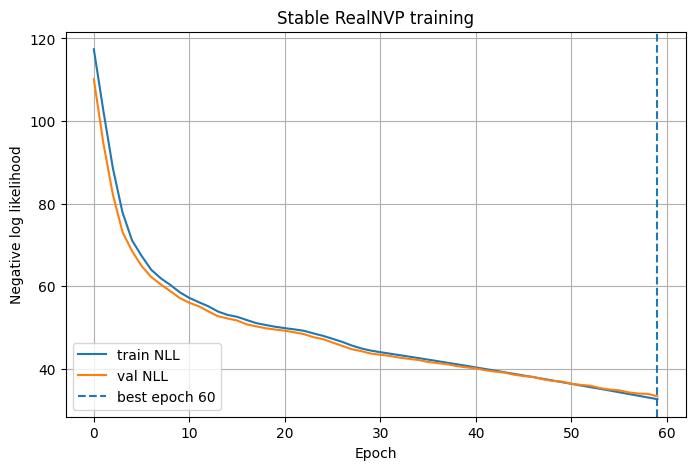

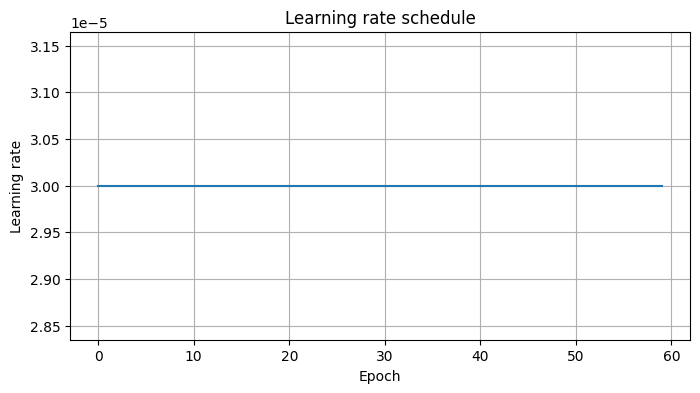

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="val NLL")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Negative log likelihood")
plt.title("Stable RealNVP training")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.show()

## 14. Calcolo score NLL

In [14]:
def compute_flow_scores(model, X, batch_size=4096):
    dataset = FlowDataset(X)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    scores = []
    log_probs = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            logp = model.log_prob(X_batch)
            nll = -logp

            scores.append(nll.cpu().numpy())
            log_probs.append(logp.cpu().numpy())

    return np.concatenate(scores), np.concatenate(log_probs)


scores_train, logp_train = compute_flow_scores(flow, A_train_norm)
scores_bg, logp_bg = compute_flow_scores(flow, A_bg_norm)
scores_sig, logp_sig = compute_flow_scores(flow, A_sig_norm)

def print_score_summary(name, scores):
    print("\n", name)
    print("mean:", scores.mean())
    print("std:", scores.std())
    print("median:", np.median(scores))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))

print_score_summary("train NLL", scores_train)
print_score_summary("background NLL", scores_bg)
print_score_summary("signal NLL", scores_sig)


 train NLL
mean: 32.514526
std: 93.40495
median: 28.64618
quantiles: [-5.17227173e-01  1.06390614e+01  1.48732285e+01  2.22401810e+01
  2.86461792e+01  3.72450790e+01  5.96000278e+01  8.78310291e+01
  2.33246331e+02  2.86650527e+04]

 background NLL
mean: 32.52054
std: 41.91469
median: 28.771463
quantiles: [1.46712494e+00 1.04630268e+01 1.48345310e+01 2.22898464e+01
 2.87714634e+01 3.74692297e+01 6.00958231e+01 8.86741184e+01
 2.58653798e+02 1.10018008e+04]

 signal NLL
mean: 7921.84
std: 243873.05
median: 56.3163
quantiles: [8.19142151e+00 2.12060979e+01 2.87235878e+01 4.27949638e+01
 5.63162994e+01 7.57676811e+01 1.30349875e+02 2.59417292e+02
 1.99421606e+06 2.18114700e+07]


## 15. ROC/AUC e distribuzioni

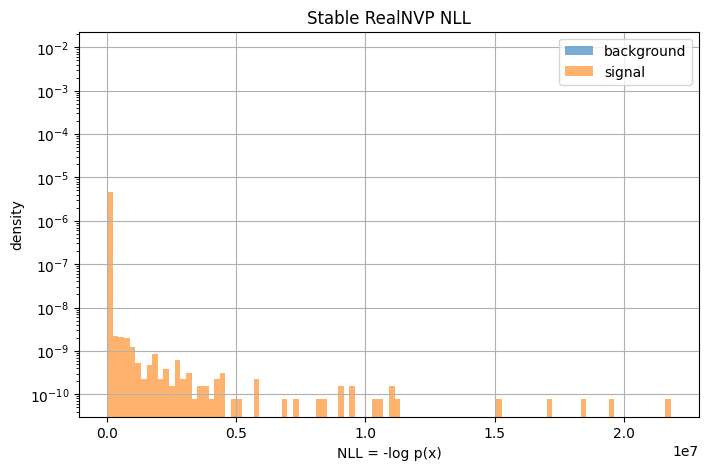

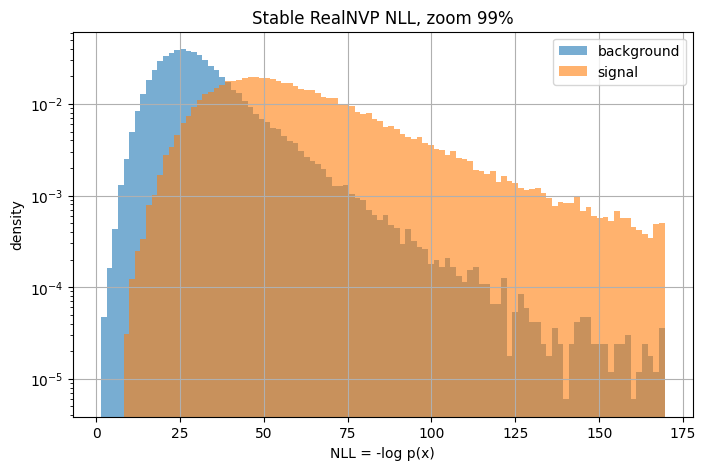


Stable RealNVP NLL ROC
AUC: 0.8713137467934208
AUC inverted: 0.12868625320657914
Best AUC: 0.8713137467934208


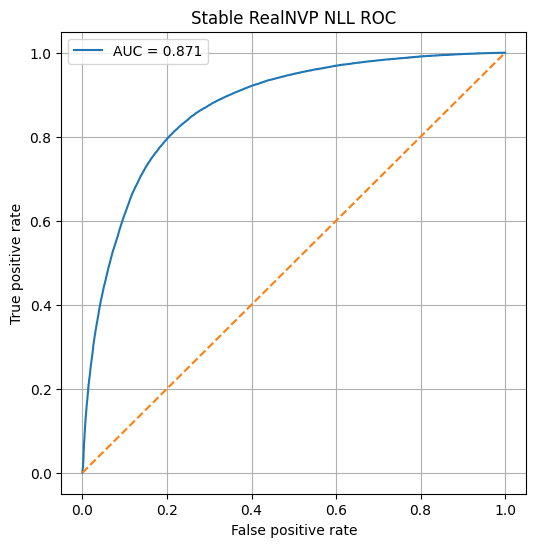

In [15]:
def evaluate_binary_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, _ = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title, zoom_percentile=None):
    plt.figure(figsize=(8, 5))

    if zoom_percentile is not None:
        hi = np.percentile(np.concatenate([bg_scores, sig_scores]), zoom_percentile)
        plot_range = (min(bg_scores.min(), sig_scores.min()), hi)
    else:
        plot_range = None

    plt.hist(bg_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("NLL = -log p(x)")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_score_distribution(scores_bg, scores_sig, "Stable RealNVP NLL")
plot_score_distribution(scores_bg, scores_sig, "Stable RealNVP NLL, zoom 99%", zoom_percentile=99)

auc_flow, auc_flow_inv, best_auc_flow = evaluate_binary_scores(
    scores_bg,
    scores_sig,
    "Stable RealNVP NLL ROC",
)

## 16. Controllo train vs test background

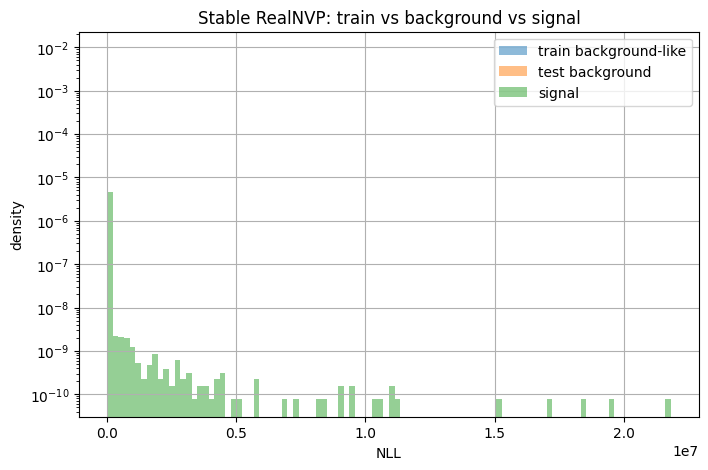

Train vs test background AUC: 0.50265796355
Train vs test background AUC inverted: 0.49734203644999997
Best train-vs-test-background AUC: 0.50265796355


In [16]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("NLL")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)
    best_auc_tb = max(auc_tb, auc_tb_inv)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", best_auc_tb)

    return auc_tb, auc_tb_inv, best_auc_tb


auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(
    scores_train,
    scores_bg,
    scores_sig,
    "Stable RealNVP: train vs background vs signal",
)

## 17. Track-only diagnostic

In [17]:
# Diagnostica supervisionata sulle sole track aggregate.
# Non è anomaly detection, serve a capire se le tracce aggregate separano già molto.

A_train_tracks_only = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=False,
    use_tracks=True,
)

A_bg_tracks_only = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=False,
    use_tracks=True,
)

A_sig_tracks_only = build_aggregate_matrix(
    X_jets_sig,
    X_tracks_sig,
    mask_sig,
    use_jets=False,
    use_tracks=True,
)

center_to = np.median(A_train_tracks_only, axis=0, keepdims=True)
q25_to = np.percentile(A_train_tracks_only, 25, axis=0, keepdims=True)
q75_to = np.percentile(A_train_tracks_only, 75, axis=0, keepdims=True)
scale_to = np.maximum(q75_to - q25_to, 1e-6)

A_bg_tracks_only_norm = np.clip(((A_bg_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_tracks_only_norm = np.clip(((A_sig_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

X_clf_to = np.concatenate([A_bg_tracks_only_norm, A_sig_tracks_only_norm], axis=0)
y_clf_to = np.concatenate([
    np.zeros(A_bg_tracks_only_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_tracks_only_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_to,
    y_clf_to,
    test_size=0.3,
    random_state=42,
    stratify=y_clf_to,
)

clf_to = LogisticRegression(max_iter=3000)
clf_to.fit(X_tr, y_tr)
proba_to = clf_to.predict_proba(X_te)[:, 1]
auc_track_only_logreg = roc_auc_score(y_te, proba_to)

print("Track-only supervised logistic regression AUC:", auc_track_only_logreg)

Track-only supervised logistic regression AUC: 0.9895588349261348


## 18. Sampling sanity check

sampled shape: (5000, 75)
sampled finite: True
sampled mean/std: -0.029881533 0.9406223
sampled quantiles: [-4.43042831e+01 -2.68430104e+00 -1.34385645e+00 -4.49495472e-01
 -1.23090348e-02  4.15541962e-01  1.30778127e+00  2.34425656e+00
  2.42044315e+01]


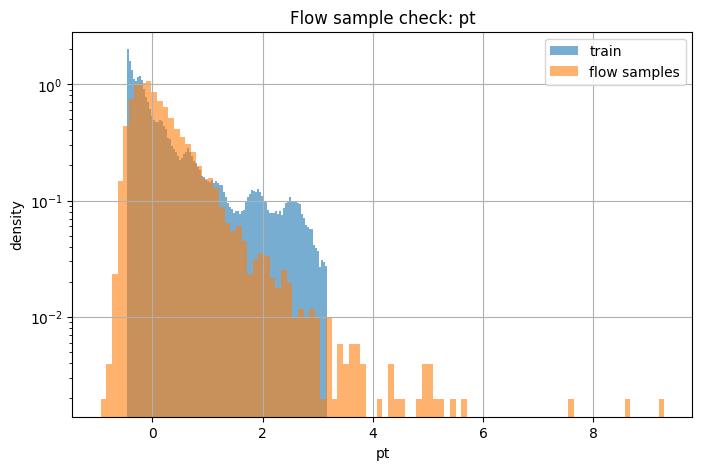

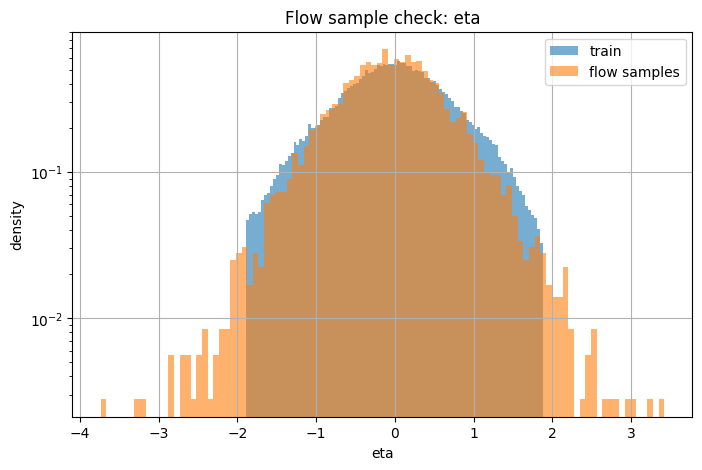

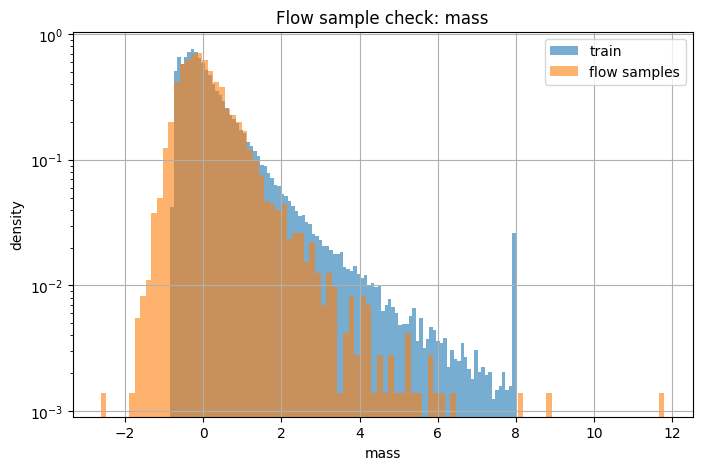

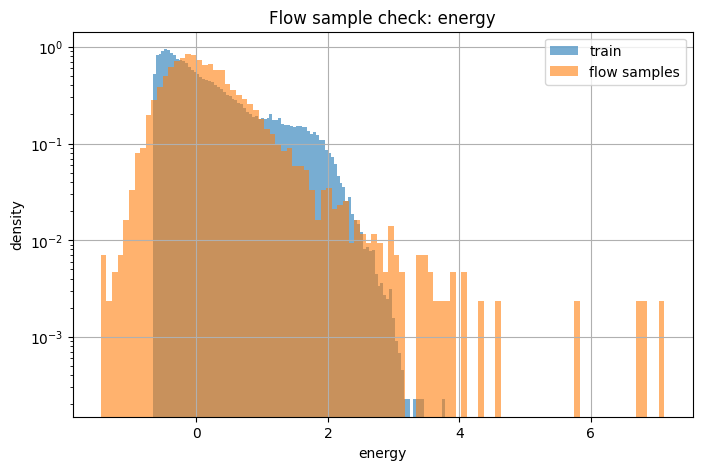

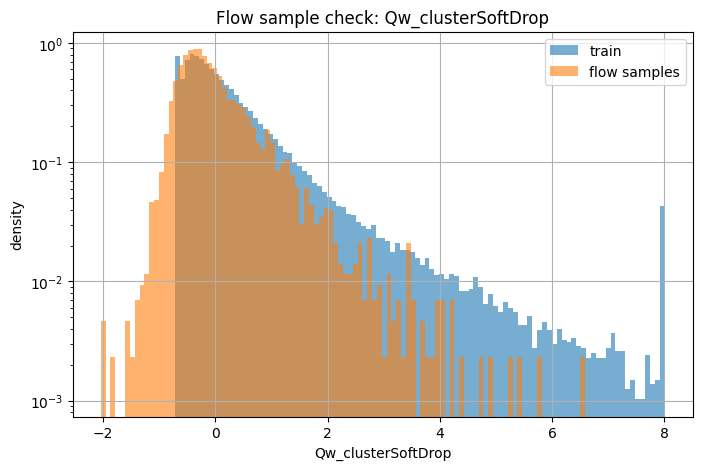

In [18]:
# Il sampling serve a vedere se il flow è meno instabile del run precedente.
# Non è fondamentale per anomaly detection, ma non dovrebbe più produrre scale assurde.

n_samples = 5000

flow.eval()
with torch.no_grad():
    z = torch.randn(n_samples, input_dim, device=device)
    x_sampled, _ = flow.inverse(z)
    x_sampled = x_sampled.cpu().numpy()

print("sampled shape:", x_sampled.shape)
print("sampled finite:", np.isfinite(x_sampled).all())
print("sampled mean/std:", x_sampled.mean(), x_sampled.std())
print("sampled quantiles:", np.percentile(x_sampled.ravel(), [0, 1, 5, 25, 50, 75, 95, 99, 100]))

for i in range(min(5, input_dim)):
    plt.figure(figsize=(8, 5))
    plt.hist(A_train_norm[:, i], bins=100, density=True, alpha=0.6, label="train")
    plt.hist(x_sampled[:, i], bins=100, density=True, alpha=0.6, label="flow samples")
    plt.yscale("log")
    plt.xlabel(aggregate_feature_names[i])
    plt.ylabel("density")
    plt.title(f"Flow sample check: {aggregate_feature_names[i]}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 19. Salvataggio

In [19]:
torch.save(
    {
        "model_state_dict": flow.state_dict(),
        "input_dim": input_dim,
        "n_flow_layers": n_flow_layers,
        "hidden_dim": hidden_dim,
        "scale_clip": scale_clip,
        "learning_rate": learning_rate,
        "aggregate_feature_names": aggregate_feature_names,
        "center": center,
        "scale": scale,
        "clip_value": CLIP_VALUE,
        "robust_scale": ROBUST_SCALE,
        "train_nll_history": train_nll_history,
        "val_nll_history": val_nll_history,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "best_val_nll": best_val_nll,
        "auc_flow": auc_flow,
        "auc_flow_inv": auc_flow_inv,
        "best_auc_flow": best_auc_flow,
        "auc_train_bg": auc_train_bg,
        "auc_train_bg_inv": auc_train_bg_inv,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_logreg": auc_logreg,
        "auc_track_only_logreg": auc_track_only_logreg,
    },
    OUTPUT_DIR / "stable_realnvp_flow.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "stable_realnvp_flow_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    logp_train=logp_train,
    logp_bg=logp_bg,
    logp_sig=logp_sig,
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc_flow=np.array(auc_flow, dtype=np.float32),
    auc_flow_inv=np.array(auc_flow_inv, dtype=np.float32),
    best_auc_flow=np.array(best_auc_flow, dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    auc_train_bg_inv=np.array(auc_train_bg_inv, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_logreg=np.array(auc_logreg, dtype=np.float32),
    auc_track_only_logreg=np.array(auc_track_only_logreg, dtype=np.float32),
)

config = {
    "dataset_name": DATASET_NAME,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "USE_JET_FEATURES": USE_JET_FEATURES,
    "USE_TRACK_AGGREGATES": USE_TRACK_AGGREGATES,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "input_dim": int(input_dim),
    "robust_scale": bool(ROBUST_SCALE),
    "clip_value": float(CLIP_VALUE),
    "n_flow_layers": int(n_flow_layers),
    "hidden_dim": int(hidden_dim),
    "scale_clip": float(scale_clip),
    "learning_rate": float(learning_rate),
    "batch_size": int(batch_size),
    "n_epochs_requested": int(n_epochs),
    "best_epoch": int(best_epoch),
    "best_val_nll": float(best_val_nll),
    "best_auc_flow": float(best_auc_flow),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_logreg": float(auc_logreg),
    "auc_track_only_logreg": float(auc_track_only_logreg),
}

with open(OUTPUT_DIR / "stable_realnvp_flow_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "stable_realnvp_flow.pt")
print(OUTPUT_DIR / "stable_realnvp_flow_scores.npz")
print(OUTPUT_DIR / "stable_realnvp_flow_config.json")

Saved:
outputs_flow_stable\stable_realnvp_flow.pt
outputs_flow_stable\stable_realnvp_flow_scores.npz
outputs_flow_stable\stable_realnvp_flow_config.json


## Come interpretare i risultati

- **NLL train/val in training**: deve essere stabile. Non deve esplodere a valori enormi.
- **Best validation NLL**: il notebook ricarica il modello migliore, non l'ultimo.
- **AUC background vs signal**: misura l'anomaly detection vera.
- **Train vs test background AUC**: deve stare vicino a 0.5. Se è alto, c'è domain shift.
- **Sampling sanity check**: i campioni non devono avere scale assurde tipo `1e10`; se succede ancora, riduci `CLIP_VALUE`, `learning_rate`, `n_flow_layers` o `scale_clip`.